Top 10% customers generate 41.68% of revenue
Highest revenue month:
month                  2017-11-01 00:00:00
total_orders                          7289
total_customers                       7183
revenue                          987765.37
average_order_value                 135.51
revenue_growth_pct               52.374694
Name: 13, dtype: object
Lowest revenue month:
month                  2016-12-01 00:00:00
total_orders                             1
total_customers                          1
revenue                               10.9
average_order_value                   10.9
revenue_growth_pct               -99.97297
Name: 2, dtype: object


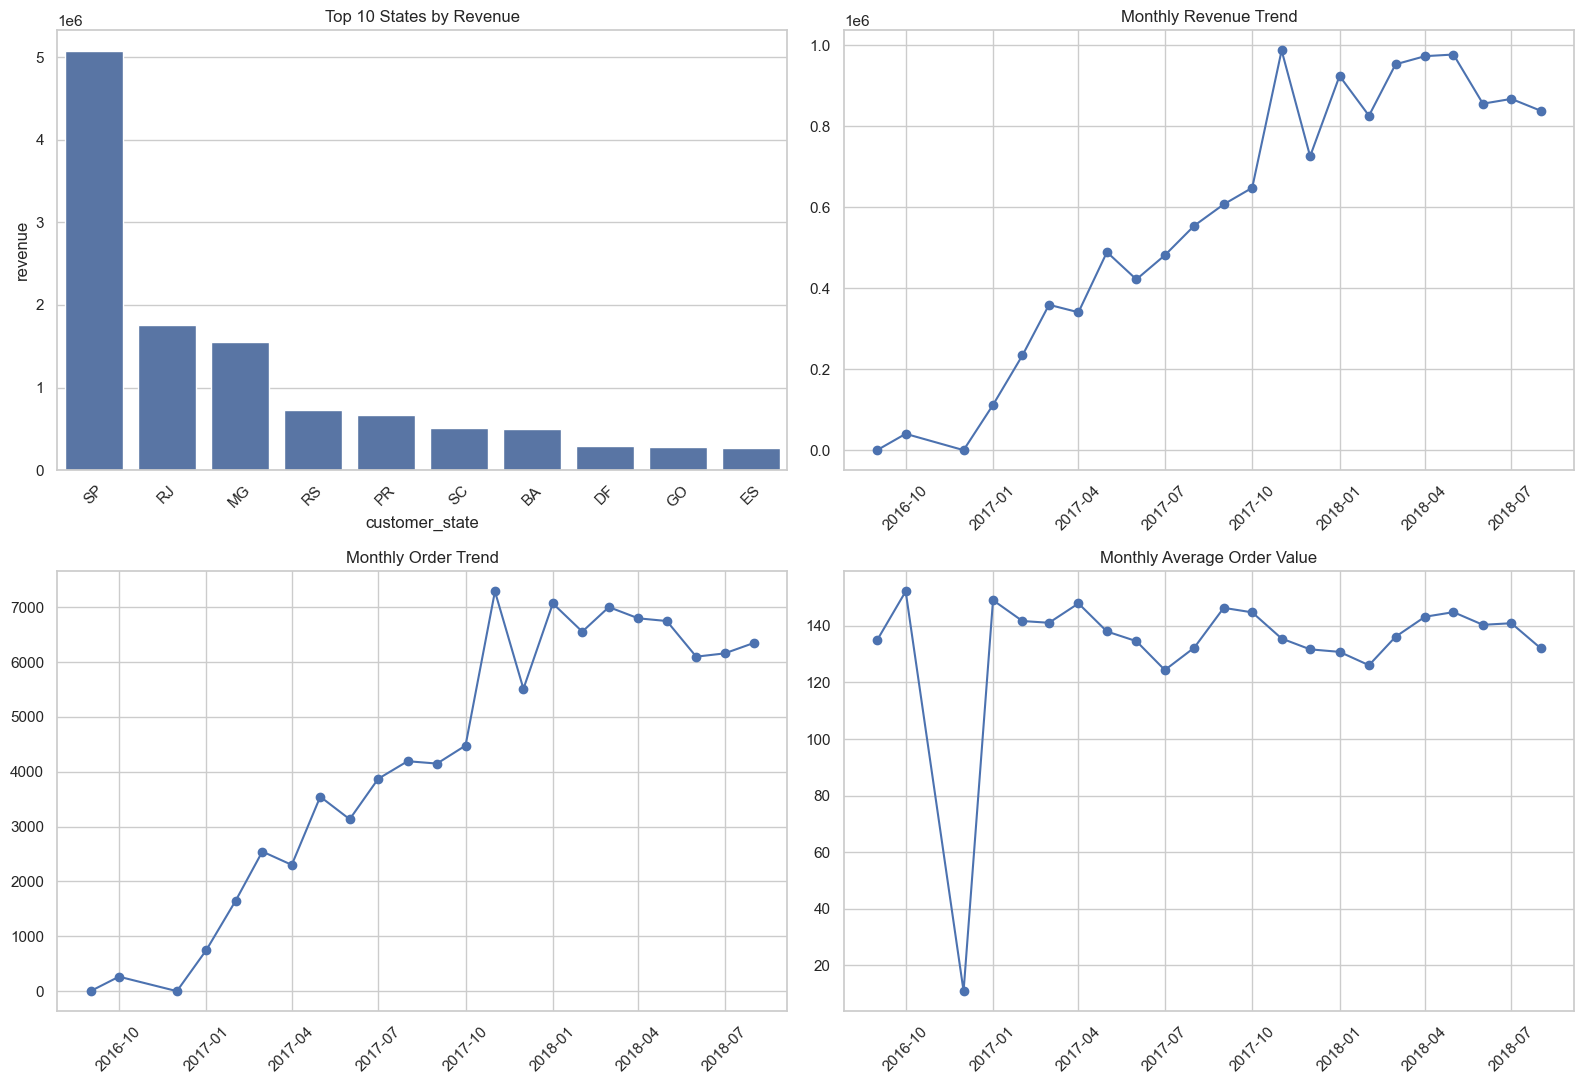

,Metric,Value
0,Total Customers,9.609600e+04
1,Total Revenue,1.322150e+07
2,Average Customer Revenue,1.375864e+02
3,Total Orders,9.944100e+04
4,Top Customer Revenue,1.344000e+04
5,Top 10% Revenue Share,4.167692e+01


In [1]:
# Step 6.4-6.15: customer and revenue analysis
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

DB_USER = os.getenv("POSTGRES_USER", "postgres")
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD")
DB_HOST = os.getenv("POSTGRES_HOST", "localhost")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")
DB_NAME = os.getenv("POSTGRES_DB")

if not DB_PASSWORD or not DB_NAME:
    raise RuntimeError(
        "Set POSTGRES_PASSWORD and POSTGRES_DB before running this notebook."
    )

engine = create_engine(
    "postgresql+psycopg2://"
    f"{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

customer_360 = pd.read_sql_query("SELECT * FROM vw_customer_360", engine)
monthly_revenue = pd.read_sql_query("SELECT * FROM vw_monthly_revenue", engine)

customer_360["customer_frequency_type"] = np.select(
    [
        customer_360["total_orders"] == 1,
        customer_360["total_orders"].between(2, 3),
        customer_360["total_orders"].between(4, 5),
        customer_360["total_orders"] >= 6,
    ],
    ["One-time", "2-3 Orders", "4-5 Orders", "6+ Orders"],
    default="Other",
)

frequency_summary = (
    customer_360["customer_frequency_type"]
    .value_counts()
    .rename_axis("customer_type")
    .reset_index(name="customers")
)

revenue_summary = customer_360["total_revenue"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

top_customers = customer_360.sort_values("total_revenue", ascending=False).head(20)[
    [
        "customer_unique_id",
        "customer_state",
        "total_orders",
        "total_revenue",
        "average_order_value",
    ]
]

state_revenue = (
    customer_360.groupby("customer_state", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("total_orders", "sum"),
        revenue=("total_revenue", "sum"),
    )
    .sort_values("revenue", ascending=False)
)

monthly_revenue["month"] = pd.to_datetime(monthly_revenue["month"])
monthly_revenue["revenue_growth_pct"] = monthly_revenue["revenue"].pct_change() * 100

customer_sorted = customer_360.sort_values("total_revenue", ascending=False).reset_index(
    drop=True
)
top_10_percent_count = max(1, int(len(customer_sorted) * 0.10))
top_10_revenue_percentage = (
    customer_sorted.head(top_10_percent_count)["total_revenue"].sum()
    / customer_sorted["total_revenue"].sum()
    * 100
)

print(f"Top 10% customers generate {top_10_revenue_percentage:.2f}% of revenue")
print("Highest revenue month:")
print(monthly_revenue.loc[monthly_revenue["revenue"].idxmax()])
print("Lowest revenue month:")
print(monthly_revenue.loc[monthly_revenue["revenue"].idxmin()])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.barplot(data=state_revenue.head(10), x="customer_state", y="revenue", ax=axes[0, 0])
axes[0, 0].set_title("Top 10 States by Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].plot(monthly_revenue["month"], monthly_revenue["revenue"], marker="o")
axes[0, 1].set_title("Monthly Revenue Trend")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].plot(monthly_revenue["month"], monthly_revenue["total_orders"], marker="o")
axes[1, 0].set_title("Monthly Order Trend")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].plot(
    monthly_revenue["month"], monthly_revenue["average_order_value"], marker="o"
)
axes[1, 1].set_title("Monthly Average Order Value")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)
customer_360.to_csv(processed_dir / "customer_360.csv", index=False)
monthly_revenue.to_csv(processed_dir / "monthly_revenue.csv", index=False)

summary_df = pd.DataFrame(
    {
        "Metric": [
            "Total Customers",
            "Total Revenue",
            "Average Customer Revenue",
            "Total Orders",
            "Top Customer Revenue",
            "Top 10% Revenue Share",
        ],
        "Value": [
            customer_360["customer_unique_id"].nunique(),
            customer_360["total_revenue"].sum(),
            customer_360["total_revenue"].mean(),
            customer_360["total_orders"].sum(),
            customer_360["total_revenue"].max(),
            top_10_revenue_percentage,
        ],
    }
)
summary_df